In [1]:
import time
import matplotlib.pyplot as plt 
import os
os.chdir('../')
import torch
import numpy as np
import torch.nn as nn
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
import random 
import psutil
from decimal import Decimal
import deepwave
import warnings
import torch.nn.functional as F
from functools import partial
from torchaudio.functional import biquad
from scipy.signal import butter
warnings.filterwarnings('ignore')
import os
from ultils.utils import *
from pyramid_loss import gaussian_kernel, create_laplacian_pyramid
os.environ['KMP_DUPLICATE_LIB_OK']='True'


libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [2]:
gpu_count = torch.cuda.device_count()
print(f"The number of available GPUs is: {gpu_count}")
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print(f"The selected GPU device is: {torch.cuda.get_device_name(DEVICE)}")
else:
    DEVICE = torch.device("cpu")
    print("No available GPUs detected, switched to using CPU")

The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


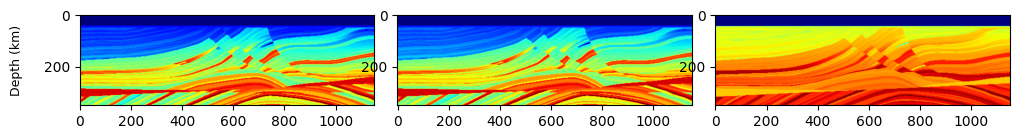

max values: tensor(4766.6040) tensor(2752.) tensor(2626.9998)
min values: tensor(1500.) tensor(800.) tensor(1009.)
model shape: torch.Size([352, 1150]) torch.Size([352, 1150]) torch.Size([352, 1150])


In [3]:
######### load data #########
dx = 10

vp_true = torch.tensor(np.load('./marmousi_model/vp_truex352x1150x10.npy'))
vs_true = torch.tensor(np.load('./marmousi_model/vs_truex352x1150x10.npy'))
rho_true = torch.tensor(np.load('./marmousi_model/rho_truex352x1150x10.npy'))


submarine_deep = 43
submarine_vp = 1500                                      #water layer vp
submarine_vs = 800  ##to obay the CFL condition                                         #water layer vs
submarine_rho = 1009
  
vp_true[:submarine_deep,:] = submarine_vp
vs_true[:submarine_deep,:] = submarine_vs
rho_true[:submarine_deep,:] = submarine_rho


fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_true.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_true.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_true.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()
print("max values:",vp_true.max(),vs_true.max(),rho_true.max())
print("min values:",vp_true.min(),vs_true.min(),rho_true.min())
print("model shape:",vp_true.shape,vs_true.shape,rho_true.shape)

17.387997
tensor(3927.0754, device='cuda:0') tensor(1847.8777, device='cuda:0')
tensor(1009., device='cuda:0') tensor(2409.4448, device='cuda:0')


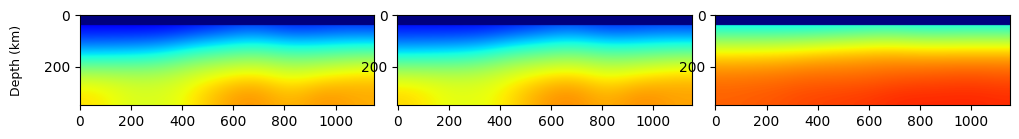

In [4]:
import scipy.ndimage
import scipy.io

sigma = 30

times = 6
if times != 0:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_n_times(vp_true, vs_true, rho_true, sigma, times, DEVICE)
else:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_once(vp_true, vs_true, rho_true, sigma, DEVICE)

snr_vp = ComputeSNR(vp_initial.detach().cpu().numpy(), \
                  vp_true.detach().cpu().numpy())

print(snr_vp)
print(vp_initial.max(),vp_initial.min())
vp_initial[:submarine_deep,:] = submarine_vp
vs_initial[:submarine_deep,:] = submarine_vs
rho_initial[:submarine_deep,:] = submarine_rho

print(rho_initial.min(),rho_initial.max())

fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_initial.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_initial.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_initial.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()

In [5]:
loss_fn = 'l1'  

if times != 0:
    ##### save path
    vp_save_path = f'./rec/reconstruction_ms/EFWI_lap_en/init_2/vp/'
    vs_save_path = f'./rec/reconstruction_ms/EFWI_lap_en/init_2/vs/'
    rho_save_path = f'./rec/reconstruction_ms/EFWI_lap_en/init_2/rho/'
    main_path = f'./log_data/log_data_ms/EFWI_lap_en/init_2/'
else:
    vp_save_path = f'./rec/reconstruction_ms/EFWI_lap_en/init_1/vp/'
    vs_save_path = f'./rec/reconstruction_ms/EFWI_lap_en/init_1/vs/'
    rho_save_path = f'./rec/reconstruction_ms/EFWI_lap_en/init_1/rho/'
    main_path = f'./log_data/log_data_ms/EFWI_lap_en/init_1/'


if not os.path.exists(main_path):
    os.makedirs(main_path)

if not os.path.exists(vp_save_path):
    os.makedirs(vp_save_path)
if not os.path.exists(vs_save_path):
    os.makedirs(vs_save_path)
if not os.path.exists(rho_save_path):
    os.makedirs(rho_save_path)
    


In [6]:
Physics = Physics_deepwave                              
                           
model_shape = [vp_true.shape[0], vp_true.shape[1]]                                 
                                                                                       
DT = 0.006                                               
F_PEAK = 8                                              
DH = dx                                                  

inpa = {                                
    'fdom': F_PEAK, 
    'dh': DH,   
    'dt': DT
}

NT = 2500

In [7]:
### load obs and src, src_loc, rec_loc
obs_file_vx = './obs_data/d_obs_vx_src.npy'
obs_file_vy = './obs_data/d_obs_vy_src.npy'
d_obs_vx = torch.tensor(np.load(obs_file_vx))
d_obs_vy = torch.tensor(np.load(obs_file_vy))

src_loc = torch.tensor(np.load('./src_rec_positions/src_loc.npy'))
rec_loc = torch.tensor(np.load('./src_rec_positions/rec_loc.npy'))
src     = torch.tensor(np.load('./sources/src.npy'))

### sum source
num_super_sources = 10
sources_per_super = 10
source_distribution = 'random'# ('random' 或 'uniform')

#### 1.
result = encode_sources(obs_data_vx = d_obs_vx.squeeze(0),
                        obs_data_vy = d_obs_vy.squeeze(0),
                        source_locations = src_loc, 
                        receiver_locations  = rec_loc, 
                        source_functions = src,
                        num_super_sources = num_super_sources,
                        sources_per_super = sources_per_super,
                        source_distribution=source_distribution
                        )

#### 2
print(f"Encoded observation data shape (vx): {result['encoded_obs_data_vx'].shape}")
print(f"Encoded observation data shape (vy): {result['encoded_obs_data_vy'].shape}")
print(f"Encoded source location shape: {result['encoded_source_locations'].shape}")
print(f"Encoded receiver location shape: {result['encoded_receiver_locations'].shape}")
print(f"Encoded source function shape: {result['encoded_source_functions'].shape}")


d_obs_vx_encode = result['encoded_obs_data_vx'].unsqueeze(0).to(DEVICE)
d_obs_vy_encode = result['encoded_obs_data_vy'].unsqueeze(0).to(DEVICE)
src_loc_encode  = result['encoded_source_locations'].to(DEVICE)
rec_loc_encode  = result['encoded_receiver_locations'].to(DEVICE)
src_encode      = result['encoded_source_functions'].to(DEVICE)



Encoded observation data shape (vx): torch.Size([10, 2500, 1130])
Encoded observation data shape (vy): torch.Size([10, 2500, 1130])
Encoded source location shape: torch.Size([10, 10, 2])
Encoded receiver location shape: torch.Size([10, 1130, 2])
Encoded source function shape: torch.Size([10, 10, 2500])


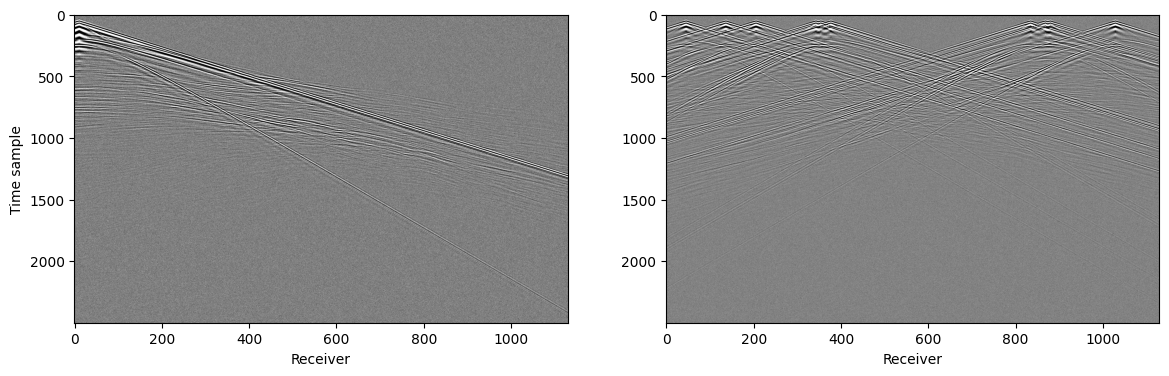

In [8]:

##### show these data
d_obs_vx_plot = d_obs_vx.squeeze(0)
d_obs_vx_en_plot = d_obs_vx_encode.squeeze(0)
vmin, vmax = torch.quantile(d_obs_vx_plot[1],
                            torch.tensor([0.01, 0.99]))
vsmin, vsmax = torch.quantile(d_obs_vx_en_plot[1],
                                 torch.tensor([0.01, 0.99]).to(DEVICE))


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(d_obs_vx_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vmin, vmax=vmax)
ax[0].set_xlabel("Receiver")
ax[0].set_ylabel("Time sample")
ax[1].imshow(d_obs_vx_en_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vsmin, vmax=vsmax)
ax[1].set_xlabel("Receiver")
plt.subplots_adjust(hspace=0.6)  
plt.show()


In [9]:
vp_initial = vp_initial.to(DEVICE)
vs_initial = vs_initial.to(DEVICE)
rho_initial = rho_initial.to(DEVICE)
vp = vp_initial.requires_grad_(True)
vs = vs_initial.requires_grad_(True)
rho = rho_initial.requires_grad_(True)

criteria = torch.nn.L1Loss(reduction='sum')
criteria_model = torch.nn.L1Loss(reduction='sum')

optimer = torch.optim.Adam([{'params': [vp], 'lr': 6.0},
                            {'params': [vs], 'lr': 4.0},
                            {'params': [rho], 'lr': 2.0}])

In [10]:
all_loss_data = []
all_loss_vx_model = []
all_loss_vy_model = []
all_loss_rho_model = []
all_loss_model =[]
SNR_vp = []
SSIM_vp = []
Loss_vp = []
ERROR_vp = []
SNR_vs = []
SSIM_vs = []
Loss_vs = []
ERROR_vs = []
SNR_rho = []
SSIM_rho = []
Loss_rho = []
ERROR_rho = []
time_each_iter = []
def get_cpu_memory():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss / 1024 ** 2 
    
def get_gpu_memory():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 ** 2
    else:
        return 0
cpu_mem_log = [] 
gpu_mem_log = []

Now inversion on level: 5
Iteration 5 = loss: 0.5431,model loss: 269059620.0000,time:6.95,snr_vp:18.167,snr_vs:18.156,snr_rho:22.562
Iteration 10 = loss: 0.5431,model loss: 269044484.0000,time:6.94,snr_vp:18.168,snr_vs:18.158,snr_rho:22.565
Iteration 15 = loss: 0.5430,model loss: 269029432.0000,time:6.95,snr_vp:18.168,snr_vs:18.160,snr_rho:22.569
Iteration 20 = loss: 0.5430,model loss: 269014680.0000,time:6.94,snr_vp:18.168,snr_vs:18.162,snr_rho:22.572


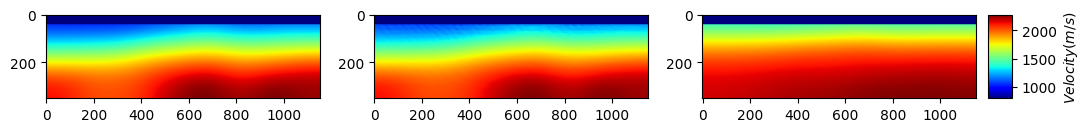

Iteration 25 = loss: 0.5429,model loss: 269000100.0000,time:7.06,snr_vp:18.168,snr_vs:18.163,snr_rho:22.575
Iteration 30 = loss: 0.5428,model loss: 268985952.0000,time:6.95,snr_vp:18.169,snr_vs:18.165,snr_rho:22.578
Iteration 35 = loss: 0.5428,model loss: 268972044.0000,time:6.94,snr_vp:18.169,snr_vs:18.166,snr_rho:22.581
Iteration 40 = loss: 0.5427,model loss: 268958448.0000,time:6.96,snr_vp:18.169,snr_vs:18.167,snr_rho:22.583


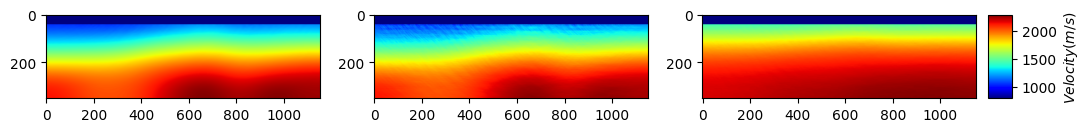

Iteration 45 = loss: 0.5427,model loss: 268944844.0000,time:6.95,snr_vp:18.169,snr_vs:18.167,snr_rho:22.586
Iteration 50 = loss: 0.5426,model loss: 268931208.0000,time:6.94,snr_vp:18.170,snr_vs:18.168,snr_rho:22.589
Now inversion on level: 4
Iteration 5 = loss: 1.1446,model loss: 267752308.0000,time:6.94,snr_vp:18.196,snr_vs:18.237,snr_rho:22.672
Iteration 10 = loss: 1.1230,model loss: 265709132.0000,time:6.94,snr_vp:18.233,snr_vs:18.299,snr_rho:22.767
Iteration 15 = loss: 1.1087,model loss: 263722936.0000,time:6.96,snr_vp:18.270,snr_vs:18.342,snr_rho:22.843
Iteration 20 = loss: 1.0994,model loss: 261918972.0000,time:6.94,snr_vp:18.305,snr_vs:18.376,snr_rho:22.900


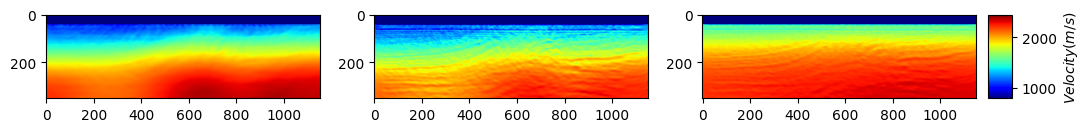

Iteration 25 = loss: 1.0929,model loss: 260353020.0000,time:6.95,snr_vp:18.338,snr_vs:18.408,snr_rho:22.944
Iteration 30 = loss: 1.0881,model loss: 258998844.0000,time:6.95,snr_vp:18.367,snr_vs:18.436,snr_rho:22.982
Iteration 35 = loss: 1.0845,model loss: 257839240.0000,time:6.95,snr_vp:18.394,snr_vs:18.460,snr_rho:23.013
Iteration 40 = loss: 1.0814,model loss: 256819016.0000,time:6.95,snr_vp:18.419,snr_vs:18.481,snr_rho:23.041


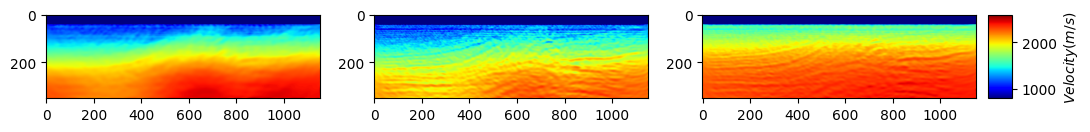

Iteration 45 = loss: 1.0788,model loss: 255918496.0000,time:6.96,snr_vp:18.441,snr_vs:18.499,snr_rho:23.065
Iteration 50 = loss: 1.0767,model loss: 255120960.0000,time:6.96,snr_vp:18.462,snr_vs:18.516,snr_rho:23.086
Now inversion on level: 3
Iteration 5 = loss: 2.9647,model loss: 243703044.0000,time:6.96,snr_vp:18.788,snr_vs:18.982,snr_rho:23.265
Iteration 10 = loss: 2.6406,model loss: 233792504.0000,time:7.97,snr_vp:19.120,snr_vs:19.416,snr_rho:23.331
Iteration 15 = loss: 2.4866,model loss: 225757496.0000,time:7.97,snr_vp:19.414,snr_vs:19.767,snr_rho:23.366
Iteration 20 = loss: 2.4059,model loss: 219149612.0000,time:7.97,snr_vp:19.660,snr_vs:20.049,snr_rho:23.399


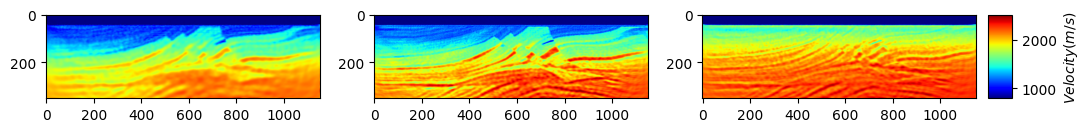

Iteration 25 = loss: 2.3527,model loss: 213774548.0000,time:7.98,snr_vp:19.863,snr_vs:20.280,snr_rho:23.437
Iteration 30 = loss: 2.3191,model loss: 209390196.0000,time:7.99,snr_vp:20.032,snr_vs:20.476,snr_rho:23.477
Iteration 35 = loss: 2.2928,model loss: 205603848.0000,time:7.97,snr_vp:20.176,snr_vs:20.644,snr_rho:23.518
Iteration 40 = loss: 2.2684,model loss: 202331632.0000,time:7.95,snr_vp:20.301,snr_vs:20.793,snr_rho:23.559


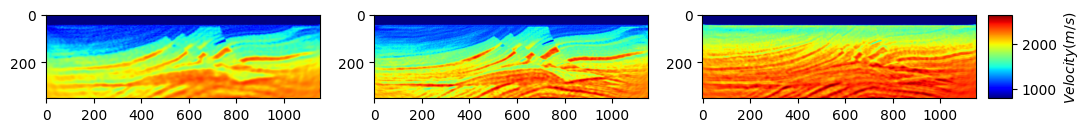

Iteration 45 = loss: 2.2489,model loss: 199460564.0000,time:7.96,snr_vp:20.411,snr_vs:20.933,snr_rho:23.600
Iteration 50 = loss: 2.2373,model loss: 196900888.0000,time:7.96,snr_vp:20.511,snr_vs:21.060,snr_rho:23.641
Now inversion on level: 2
Iteration 5 = loss: 5.4100,model loss: 181712600.0000,time:8.03,snr_vp:21.009,snr_vs:21.542,snr_rho:23.759
Iteration 10 = loss: 5.3130,model loss: 172449960.0000,time:7.96,snr_vp:21.336,snr_vs:21.789,snr_rho:23.876
Iteration 15 = loss: 5.2684,model loss: 166928936.0000,time:7.94,snr_vp:21.550,snr_vs:21.956,snr_rho:23.973
Iteration 20 = loss: 4.8917,model loss: 163275252.0000,time:7.95,snr_vp:21.708,snr_vs:22.080,snr_rho:24.048


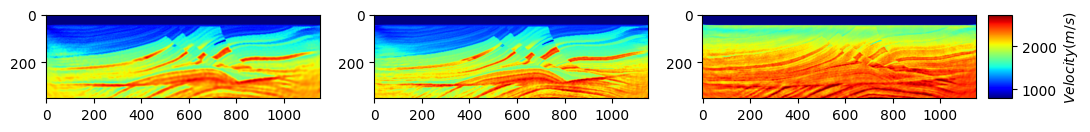

Iteration 25 = loss: 4.7495,model loss: 160422092.0000,time:7.94,snr_vp:21.834,snr_vs:22.176,snr_rho:24.111
Iteration 30 = loss: 4.8829,model loss: 157953900.0000,time:7.96,snr_vp:21.947,snr_vs:22.267,snr_rho:24.164
Iteration 35 = loss: 4.8462,model loss: 155922080.0000,time:7.96,snr_vp:22.044,snr_vs:22.347,snr_rho:24.217
Iteration 40 = loss: 4.6838,model loss: 154190532.0000,time:7.96,snr_vp:22.131,snr_vs:22.415,snr_rho:24.265


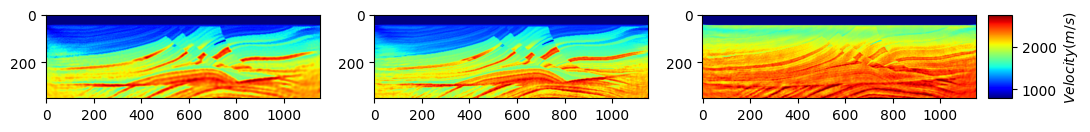

Iteration 45 = loss: 4.6329,model loss: 152597564.0000,time:8.07,snr_vp:22.208,snr_vs:22.483,snr_rho:24.307
Iteration 50 = loss: 4.7329,model loss: 151256232.0000,time:7.98,snr_vp:22.276,snr_vs:22.539,snr_rho:24.349
Now inversion on level: 1
Iteration 5 = loss: 11.9582,model loss: 149216976.0000,time:7.96,snr_vp:22.368,snr_vs:22.621,snr_rho:24.382
Iteration 10 = loss: 11.8900,model loss: 147563768.0000,time:7.95,snr_vp:22.428,snr_vs:22.666,snr_rho:24.416
Iteration 15 = loss: 11.0296,model loss: 146492976.0000,time:7.97,snr_vp:22.478,snr_vs:22.700,snr_rho:24.438
Iteration 20 = loss: 10.8417,model loss: 145552852.0000,time:7.95,snr_vp:22.519,snr_vs:22.728,snr_rho:24.454


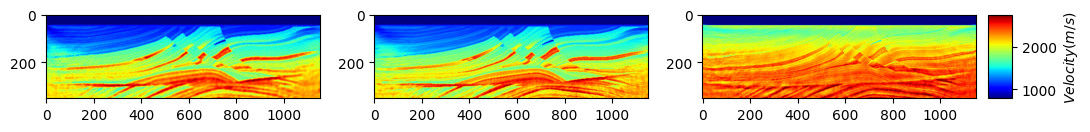

Iteration 25 = loss: 11.0379,model loss: 144827780.0000,time:7.95,snr_vp:22.558,snr_vs:22.758,snr_rho:24.471
Iteration 30 = loss: 10.5883,model loss: 144163712.0000,time:7.96,snr_vp:22.591,snr_vs:22.778,snr_rho:24.488
Iteration 35 = loss: 10.8981,model loss: 143611872.0000,time:7.97,snr_vp:22.620,snr_vs:22.799,snr_rho:24.503
Iteration 40 = loss: 10.6563,model loss: 143184108.0000,time:7.95,snr_vp:22.646,snr_vs:22.820,snr_rho:24.516


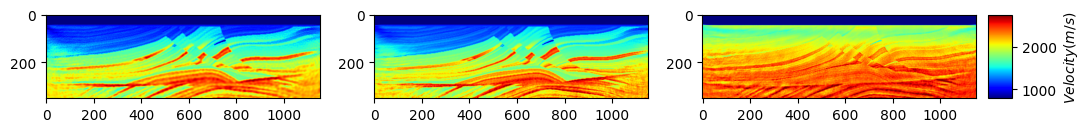

Iteration 45 = loss: 10.6977,model loss: 142730252.0000,time:7.97,snr_vp:22.671,snr_vs:22.835,snr_rho:24.530
Iteration 50 = loss: 10.8260,model loss: 142357588.0000,time:8.01,snr_vp:22.692,snr_vs:22.849,snr_rho:24.542
Now inversion on level: 0
Iteration 5 = loss: 68.5015,model loss: 142119452.0000,time:7.96,snr_vp:22.699,snr_vs:22.859,snr_rho:24.546
Iteration 10 = loss: 68.4830,model loss: 142103740.0000,time:7.97,snr_vp:22.700,snr_vs:22.859,snr_rho:24.545
Iteration 15 = loss: 68.4802,model loss: 142129868.0000,time:7.99,snr_vp:22.700,snr_vs:22.858,snr_rho:24.544
Iteration 20 = loss: 68.4785,model loss: 142171072.0000,time:7.95,snr_vp:22.699,snr_vs:22.858,snr_rho:24.543


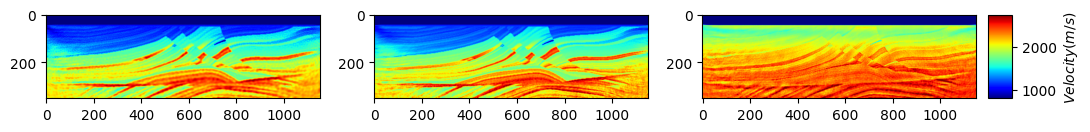

Iteration 25 = loss: 68.4773,model loss: 142220728.0000,time:8.00,snr_vp:22.698,snr_vs:22.857,snr_rho:24.542
Iteration 30 = loss: 68.4762,model loss: 142276632.0000,time:8.06,snr_vp:22.697,snr_vs:22.856,snr_rho:24.540
Iteration 35 = loss: 68.4753,model loss: 142337700.0000,time:7.96,snr_vp:22.696,snr_vs:22.855,snr_rho:24.538
Iteration 40 = loss: 68.4746,model loss: 142402480.0000,time:7.96,snr_vp:22.695,snr_vs:22.854,snr_rho:24.536


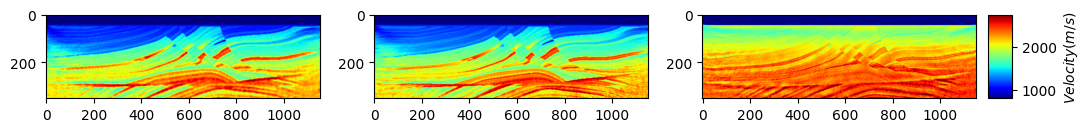

Iteration 45 = loss: 68.4739,model loss: 142469796.0000,time:7.97,snr_vp:22.694,snr_vs:22.853,snr_rho:24.535
Iteration 50 = loss: 68.4733,model loss: 142538348.0000,time:7.94,snr_vp:22.692,snr_vs:22.852,snr_rho:24.533
Running complete in 38m  52s


In [11]:
# Run optimisation/inversion

# import time
t_start = time.time()
mini_batches = 5
ITERATION = 50 


levels  = 6

levels_1 = np.arange(0,levels,1)

for level in reversed(levels_1):
    print('Now inversion on level:',level)

    for iter in range(ITERATION):
        loss_data_minibatch = []
        
        time_each_bath_start = time.time()
        for batch in range(mini_batches):
       
            optimer.zero_grad()
        
            src_loc_batch = src_loc_encode[batch::mini_batches].to(DEVICE)
            rec_loc_batch = rec_loc_encode[batch::mini_batches].to(DEVICE)
            src_batch = src_encode[batch::mini_batches].to(DEVICE) ## for true source
                
            physics = Physics(inpa['dh'], inpa['dt'],inpa['fdom'] ,size=NT,src=src_batch,
                        src_loc=src_loc_batch, rec_loc=rec_loc_batch
                        )

            with torch.no_grad():
            
                vp[:submarine_deep,:] = submarine_vp
                vs[:submarine_deep,:] = submarine_vs
                rho[:submarine_deep,:] = submarine_rho
            
                vp[vp>vp_true.max()] = vp_true.max()
                vp[vp<vp_true.min()] = vp_true.min()
        
                vs[vs>vs_true.max()] = vs_true.max()
                vs[vs<vs_true.min()] = vs_true.min()
        
                rho[rho>rho_true.max()] = rho_true.max()
                rho[rho<rho_true.min()] = rho_true.min()
               
                vp = vp.requires_grad_(True)
                vs = vs.requires_grad_(True)
                rho = rho.requires_grad_(True)          
        

            vp = vp.to(DEVICE)
            vs = vs.to(DEVICE)
            rho = rho.to(DEVICE)
            
    
            taux_est = physics(vp,vs,rho) 
            taux_vx_est_filtered = taux_est[0].to(DEVICE)
            taux_vy_est_filtered = taux_est[1].to(DEVICE)
            
            
            kernel_size = 5
            channels = taux_vx_est_filtered.shape[1]
            sigma = 3
            dtype = torch.float
            kernel = gaussian_kernel(size=kernel_size, channels=channels, sigma=sigma, dtype=dtype, device=DEVICE)
            
            
            pyramids_taux_vx_est_filtered = create_laplacian_pyramid(taux_vx_est_filtered, kernel=kernel, levels=levels
                                                        )
            pyramids_taux_vy_est_filtered = create_laplacian_pyramid(taux_vy_est_filtered, kernel=kernel, levels=levels
                                                        )
            
            taux_est_all = torch.cat((pyramids_taux_vx_est_filtered[level],pyramids_taux_vy_est_filtered[level]),dim=1).to(DEVICE)
            #print(taux_est_all.shape)
            #print(taux_est_all)
            d_obs_vx_filtered = d_obs_vx_encode[:, batch::mini_batches].to(DEVICE)
            d_obs_vy_filtered = d_obs_vy_encode[:, batch::mini_batches].to(DEVICE)
            
            pyramids_d_obs_vx_filtered = create_laplacian_pyramid(d_obs_vx_filtered, kernel=kernel, levels=levels
                                                        )
            pyramids_d_obs_vy_filtered = create_laplacian_pyramid(d_obs_vy_filtered, kernel=kernel, levels=levels
                                                        )
            
            d_obs_filtered_all = torch.cat((pyramids_d_obs_vx_filtered[level],pyramids_d_obs_vy_filtered[level]),dim=1).to(DEVICE)

            if loss_fn == 'l1':
                criteria = torch.nn.L1Loss(reduction='mean')
                loss_data = 1.0e10*criteria(taux_est_all, d_obs_filtered_all)
            if loss_fn == 'l2':
                criteria = torch.nn.MSELoss(reduction='mean')
                loss_data = 1.0e12*criteria(taux_est_all, d_obs_filtered_all)
            loss = loss_data
        
            loss.backward()
        
            optimer.step()
        
        all_loss_data.append(loss_data.detach().cpu().item())
        time_each_bath_end = time.time()
        time_each_iter.append(time_each_bath_end - time_each_bath_start)
        
        mem_now_cpu = get_cpu_memory()
        cpu_mem_log.append(mem_now_cpu)
        mem_now_gpu = get_gpu_memory()
        gpu_mem_log.append(mem_now_gpu)
        peak_memory = torch.cuda.memory_reserved()   / 1024**3    # GB
    
        with torch.no_grad():
            all_loss_vx_model.append(
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()
            )
        
            all_loss_vy_model.append(
                criteria_model(vs.cpu(),vs_true.cpu()).detach().numpy().item()
                )
            all_loss_rho_model.append(
                criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
            )
            all_loss_model.append(
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
            )
    
        snr_vp = ComputeSNR(vp.detach().cpu().numpy(), \
                  vp_true.detach().cpu().numpy())
        SNR_vp = np.append(SNR_vp, snr_vp)
        snr_vs = ComputeSNR(vs.detach().cpu().numpy(), \
                  vs_true.detach().cpu().numpy())
        SNR_vs = np.append(SNR_vs, snr_vs)
        snr_rho = ComputeSNR(rho.detach().cpu().numpy(), \
                  rho_true.detach().cpu().numpy())
        SNR_rho = np.append(SNR_rho, snr_rho)
 
    

        if (iter+1)%5 == 0:
            print(f"Iteration {iter + 1} = loss: {all_loss_data[-1]:.4f},model loss: {all_loss_model[-1]:.4f},time:{time_each_iter[-1]:.2f},snr_vp:{SNR_vp[-1]:.3f},snr_vs:{SNR_vs[-1]:.3f},snr_rho:{SNR_rho[-1]:.3f}")
        if (iter+1)%10==0:
            np.save(vp_save_path + 'recx_iter_%s_%s.npy' % (iter + 1, level), vp.cpu().detach().numpy())
            np.save(vs_save_path + 'recx_iter_%s_%s.npy' % (iter + 1, level), vs.cpu().detach().numpy())
            np.save(rho_save_path + 'recx_iter_%s_%s.npy' % (iter + 1, level), rho.cpu().detach().numpy())
        if (iter+1)%20 == 0:
        
            fig, ax = plt.subplots(1,3,figsize=(12, 6))
            im0 = ax[0].imshow(vp.squeeze(0).detach().cpu(), 
                          cmap="jet") 
            im1 = ax[1].imshow(vs.squeeze(0).detach().cpu(), 
                          cmap="jet") 
            im2 = ax[2].imshow(rho.squeeze(0).detach().cpu(), 
                          cmap="jet") 
            points = ax[1].get_position().get_points()
            dy = points[1, 1] - points[0, 1]

            cax = fig.add_axes([0.91, points[0, 1], 0.02, dy])
            cax.yaxis.set_ticks_position("right")
            cbar = fig.colorbar(im1, cax=cax, orientation="vertical", 
                            extend="neither", label="$Velocity (m/s)$"
                            )
            plt.show()
t_end = time.time()
elapsed_time = t_end - t_start
print('Running complete in {:.0f}m  {:.0f}s' .format(elapsed_time //60 , elapsed_time % 60))

In [12]:

### path for log data
with torch.no_grad():
   
    np.savetxt(main_path+'all_loss_data.txt', all_loss_data,delimiter=',')
    np.savetxt(main_path+'all_loss_model.txt', all_loss_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vp_model.txt', all_loss_vx_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vs_model.txt', all_loss_vy_model, delimiter=',')
    np.savetxt(main_path+'all_loss_rho_model.txt', all_loss_rho_model, delimiter=',')
    
    np.savetxt(main_path+'vp_snr.txt', SNR_vp,delimiter=',')
    np.savetxt(main_path+'vs_snr.txt', SNR_vs,delimiter=',')
    np.savetxt(main_path+'rho_snr.txt', SNR_rho,delimiter=',')

    
    np.savetxt(main_path+'time.txt',time_each_iter , delimiter=',')
    
    np.savetxt(main_path+'cpu_men_log.txt',cpu_mem_log , delimiter=',')
    np.savetxt(main_path+'gpu_men_log.txt',gpu_mem_log , delimiter=',')
